In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All imports successful")

All imports successful


In [2]:
# Load fraud dataset
df = pd.read_csv('../data/raw/fraud/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (284807, 31)
Rows: 284,807
Columns: 31


In [3]:
# First 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [4]:
# Data types and null check
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()

=== DATA TYPES ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== NULL VALUES ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

==

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,1.021,0.999,0.995,0.959,0.915,0.876,0.849,0.838,0.814,0.771,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,-4.797,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.214,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,-0.762,-0.406,-0.649,-0.426,-0.583,-0.468,-0.484,-0.499,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,-0.033,0.140,-0.014,0.051,0.048,0.066,-0.066,-0.004,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,0.740,0.618,0.663,0.493,0.649,0.523,0.400,0.501,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,12.019,7.848,7.127,10.527,8.878,17.315,9.254,5.041,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


=== CLASS DISTRIBUTION ===
Non-Fraud (0): 284,315 (99.827%)
Fraud    (1): 492 (0.173%)

Imbalance ratio: 578:1


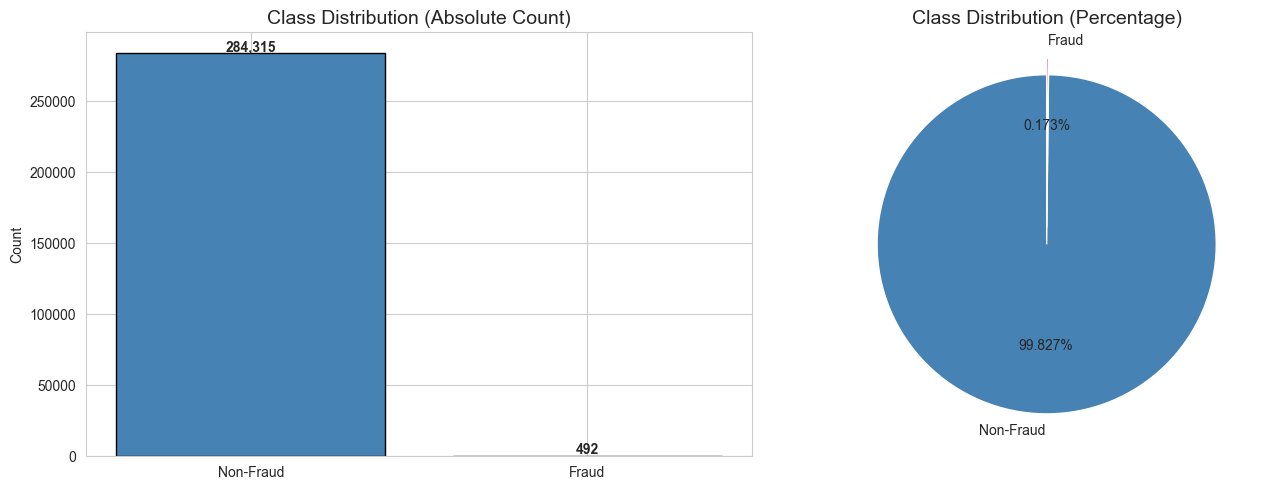

Plot saved to reports/figures/


In [5]:
# Count fraud vs non-fraud
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Non-Fraud (0): {class_counts[0]:,} ({class_pct[0]:.3f}%)")
print(f"Fraud    (1): {class_counts[1]:,} ({class_pct[1]:.3f}%)")
print(f"\nImbalance ratio: {class_counts[0]/class_counts[1]:.0f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['Non-Fraud', 'Fraud'], class_counts.values, 
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Class Distribution (Absolute Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Fraud', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/figures/")

=== AMOUNT STATISTICS ===

Fraud transactions:
  Mean:   $122.21
  Median: $9.25
  Max:    $2125.87

Normal transactions:
  Mean:   $88.29
  Median: $22.00
  Max:    $25691.16


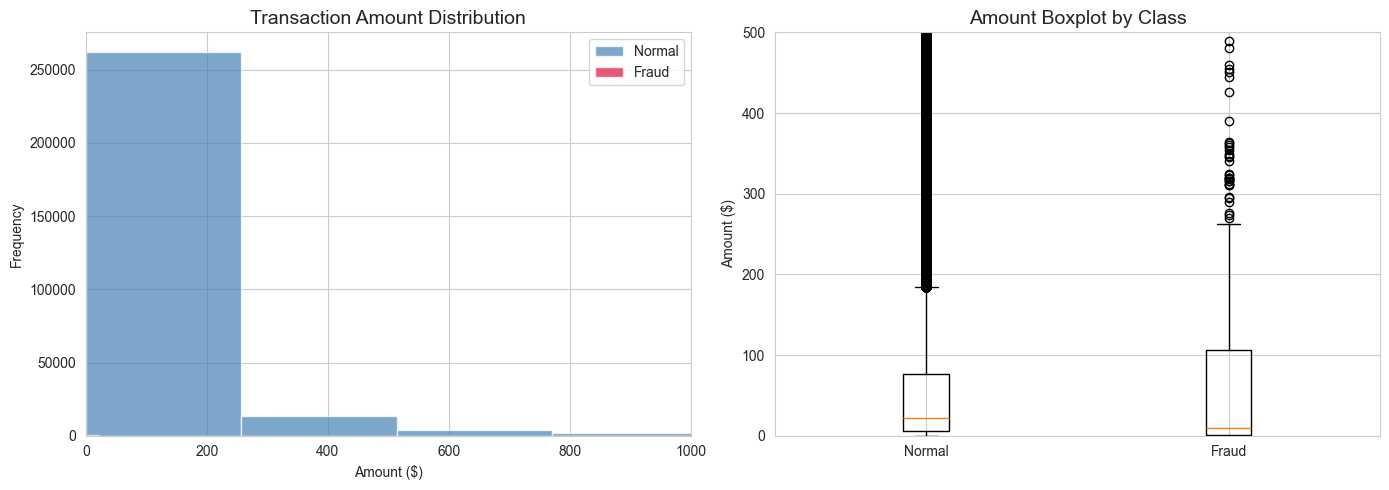

In [6]:
# Amount analysis by class
fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

print("=== AMOUNT STATISTICS ===")
print(f"\nFraud transactions:")
print(f"  Mean:   ${fraud.mean():.2f}")
print(f"  Median: ${fraud.median():.2f}")
print(f"  Max:    ${fraud.max():.2f}")

print(f"\nNormal transactions:")
print(f"  Mean:   ${normal.mean():.2f}")
print(f"  Median: ${normal.median():.2f}")
print(f"  Max:    ${normal.max():.2f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal, bins=100, color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(fraud, bins=100, color='crimson', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution', fontsize=14)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

axes[1].boxplot([normal, fraud], labels=['Normal', 'Fraud'])
axes[1].set_title('Amount Boxplot by Class', fontsize=14)
axes[1].set_ylabel('Amount ($)')
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

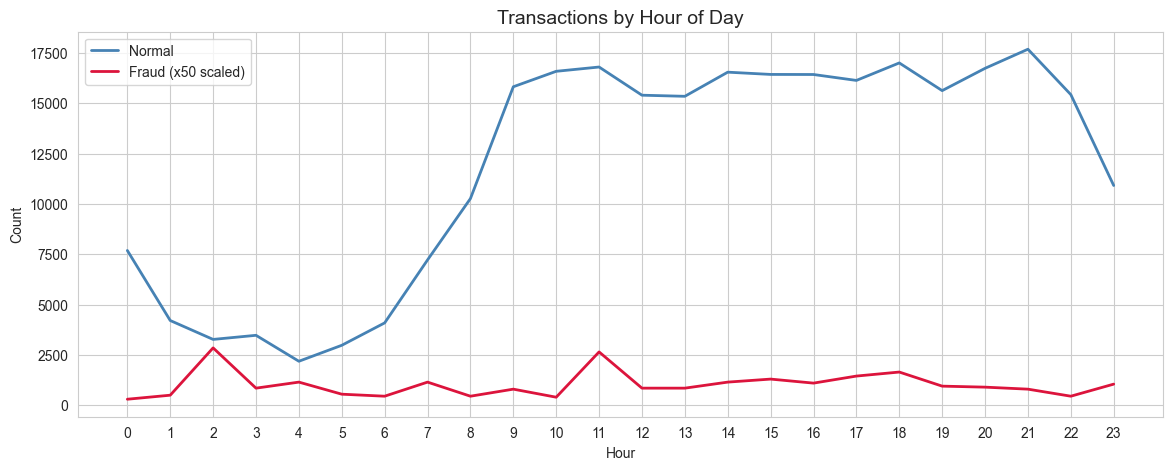

In [7]:
# Time-based pattern of fraud
df['Hour'] = (df['Time'] / 3600) % 24

fraud_by_hour = df[df['Class']==1].groupby(df['Hour'].astype(int)).size()
normal_by_hour = df[df['Class']==0].groupby(df['Hour'].astype(int)).size()

plt.figure(figsize=(14, 5))
plt.plot(normal_by_hour.index, normal_by_hour.values, 
         color='steelblue', label='Normal', linewidth=2)
plt.plot(fraud_by_hour.index, fraud_by_hour.values * 50, 
         color='crimson', label='Fraud (x50 scaled)', linewidth=2)
plt.title('Transactions by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Count')
plt.legend()
plt.xticks(range(0, 24))
plt.savefig('../reports/figures/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

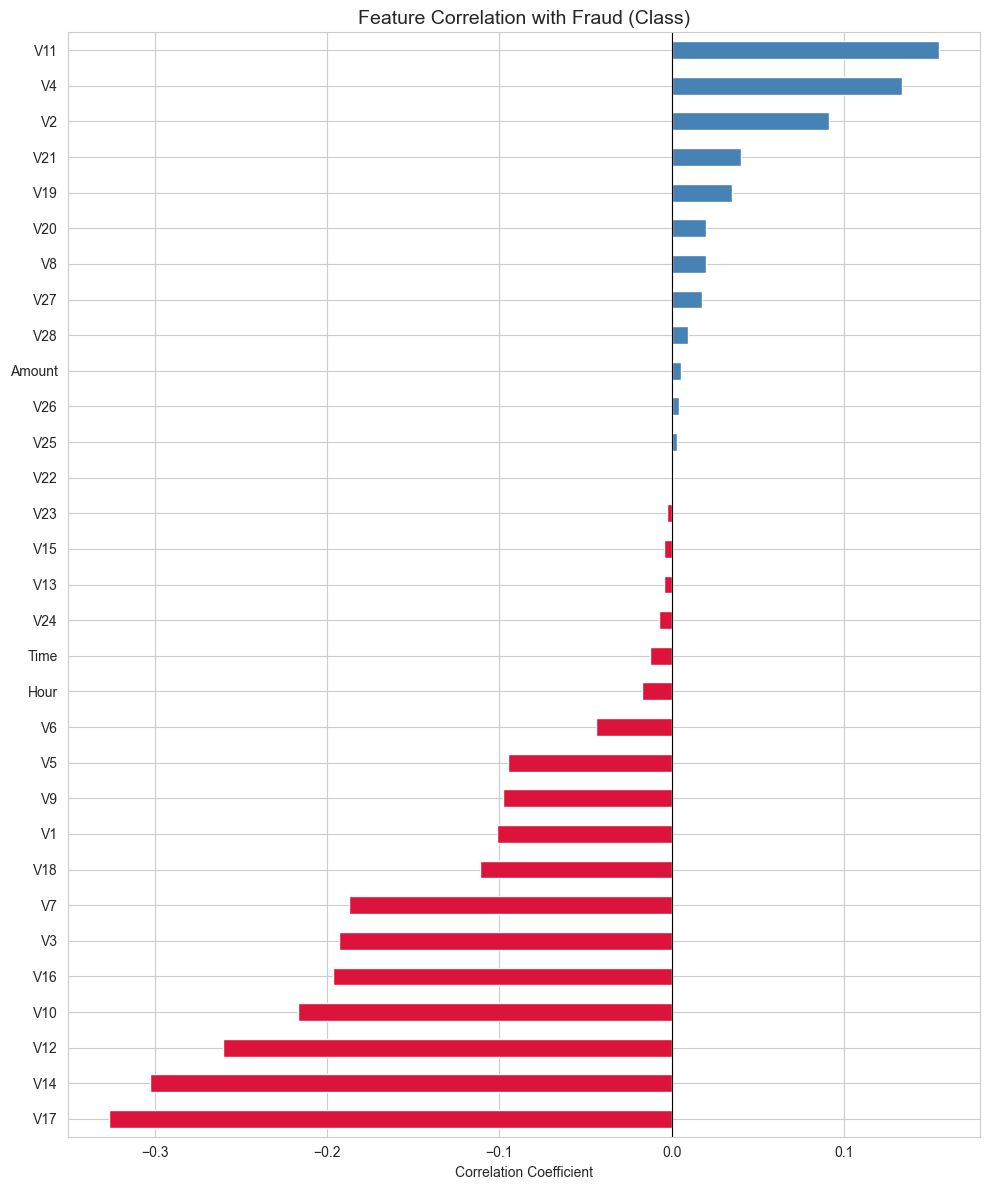


Top 5 POSITIVE correlations with fraud:
V19   0.035
V21   0.040
V2    0.091
V4    0.133
V11   0.155
Name: Class, dtype: float64

Top 5 NEGATIVE correlations with fraud:
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
Name: Class, dtype: float64


In [8]:
# Correlation with target
correlations = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(10, 12))
correlations.plot(kind='barh', 
                  color=['crimson' if x < 0 else 'steelblue' for x in correlations])
plt.title('Feature Correlation with Fraud (Class)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 POSITIVE correlations with fraud:")
print(correlations.tail(5))
print("\nTop 5 NEGATIVE correlations with fraud:")
print(correlations.head(5))

In [9]:
print("=" * 50)
print("FRAUD EDA - KEY FINDINGS SUMMARY")
print("=" * 50)

print(f"""
1. DATASET SIZE
   - Total transactions: {len(df):,}
   - Features: 28 PCA components (V1-V28) + Time + Amount

2. CLASS IMBALANCE
   - Non-fraud: {class_counts[0]:,} ({class_pct[0]:.2f}%)
   - Fraud:     {class_counts[1]:,} ({class_pct[1]:.2f}%)
   - Ratio: {class_counts[0]//class_counts[1]}:1 → SEVERE imbalance
   - Action needed: SMOTE + threshold tuning

3. AMOUNT
   - Fraud avg: ${fraud.mean():.2f} vs Normal avg: ${normal.mean():.2f}
   - Fraud amounts tend to be smaller (stealth behavior)

4. MISSING VALUES
   - None → clean dataset, no imputation needed

5. NEXT STEP
   - Preprocessing: scale Amount + Time
   - Handle imbalance with SMOTE
   - Build baseline model
""")

FRAUD EDA - KEY FINDINGS SUMMARY

1. DATASET SIZE
   - Total transactions: 284,807
   - Features: 28 PCA components (V1-V28) + Time + Amount

2. CLASS IMBALANCE
   - Non-fraud: 284,315 (99.83%)
   - Fraud:     492 (0.17%)
   - Ratio: 577:1 → SEVERE imbalance
   - Action needed: SMOTE + threshold tuning

3. AMOUNT
   - Fraud avg: $122.21 vs Normal avg: $88.29
   - Fraud amounts tend to be smaller (stealth behavior)

4. MISSING VALUES
   - None → clean dataset, no imputation needed

5. NEXT STEP
   - Preprocessing: scale Amount + Time
   - Handle imbalance with SMOTE
   - Build baseline model

